In [27]:
import sys
sys.path.insert(0, r"D:\OCRbyGPU\PIL_fix")
import os
import cv2  
import ultralytics
from ultralytics import YOLO
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
import matplotlib.pyplot as plt
import numpy as np

Shape: (326, 489, 3)


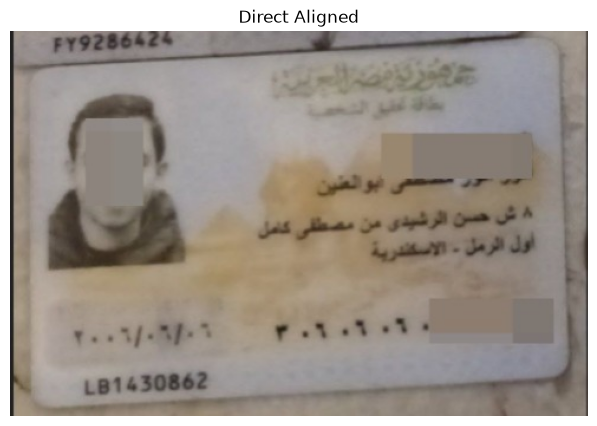

In [28]:
direct_aligned = cv2.imread(
    r"c:\Users\HP\Desktop\WhatsApp Image 2026-08-24 at 1.49.30 PM.jpeg"
)
print("Shape:", direct_aligned.shape)
plt.figure(figsize=(8, 5))
plt.imshow(
    cv2.cvtColor(
        direct_aligned,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Direct Aligned")
plt.axis("off")
plt.show()

Gray shape: (326, 489)


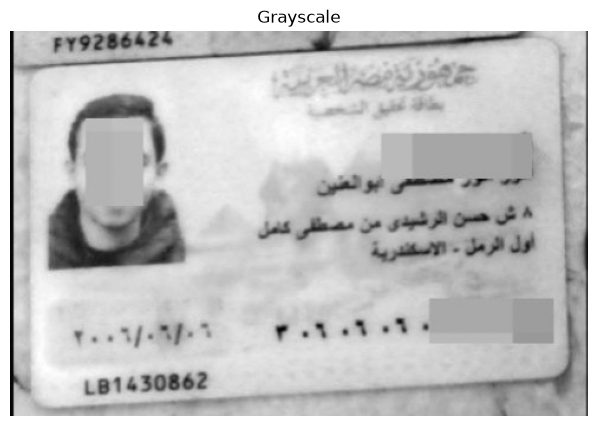

In [29]:
gray = cv2.cvtColor(
    direct_aligned,
    cv2.COLOR_BGR2GRAY
)

print("Gray shape:", gray.shape)

plt.figure(figsize=(8, 5))

plt.imshow(
    gray,
    cmap="gray"
)

plt.title("Grayscale")

plt.axis("off")

plt.show()

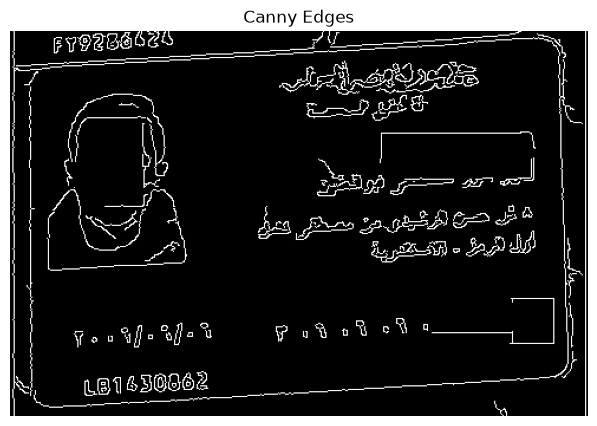

In [30]:
edges = cv2.Canny(
    gray,
    25,
    100
)
plt.figure(figsize=(8, 5))

plt.imshow(
    edges,
    cmap="gray"
)

plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [31]:
lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=80,
    minLineLength=200,
    maxLineGap=30
)
len(lines)

9

In [32]:
lines[1]

array([[ 44,  29, 379,  11]], dtype=int32)

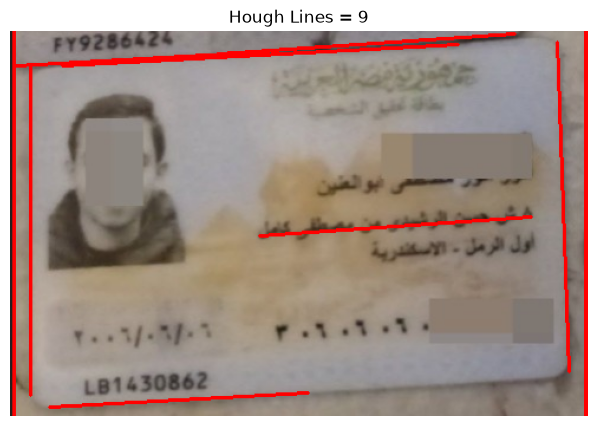

In [33]:
line_image = direct_aligned.copy()

for line in lines:

    x1, y1, x2, y2 = line[0]

    cv2.line(
        line_image,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        2
    )

plt.figure(figsize=(10, 5))

plt.imshow(
    cv2.cvtColor(
        line_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Hough Lines = {len(lines)}"
)

plt.axis("off")

plt.show()

# first line 

In [34]:
x1, y1, x2, y2 = lines[0][0]
x1

np.int32(487)

# len 

In [35]:
length = np.sqrt(
    (x2 - x1)**2 +
    (y2 - y1)**2
)

print("x1:", x1)
print("y1:", y1)
print("x2:", x2)
print("y2:", y2)
print("Length:", length)

x1: 487
y1: 325
x2: 487
y2: 0
Length: 325.0


# angle

In [36]:
angle = np.arctan2(
        y2 - y1,
        x2 - x1
    )

print("Angle:", angle)

Angle: -1.5707963267948966


In [37]:
for i, line in enumerate(lines):

    x1, y1, x2, y2 = line[0]

    length = np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    angle = np.degrees(
        np.arctan2(
            y2 - y1,
            x2 - x1
        )
    )

    print(
        f"Line {i}: "
        f"Length = {length:.2f}, "
        f"Angle = {angle:.2f}°"
    )

Line 0: Length = 325.00, Angle = -90.00°
Line 1: Length = 335.48, Angle = -3.08°
Line 2: Length = 325.00, Angle = -90.00°
Line 3: Length = 279.00, Angle = -90.00°
Line 4: Length = 214.34, Angle = -3.21°
Line 5: Length = 279.18, Angle = 87.95°
Line 6: Length = 219.33, Angle = -3.14°
Line 7: Length = 251.58, Angle = -3.87°
Line 8: Length = 230.56, Angle = -3.98°


In [38]:
angles = []

for line in lines:

    x1, y1, x2, y2 = line[0]

    length = np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    angle = np.degrees(
        np.arctan2(
            y2 - y1,
            x2 - x1
        )
    )

    if length > 200 and abs(angle) < 10:

        angles.append(angle)

print("Accepted angles:", angles)
print("Number of accepted lines:", len(angles))

Accepted angles: [np.float64(-3.075621641079249), np.float64(-3.209486317791986), np.float64(-3.1363583683325875), np.float64(-3.874673203565136), np.float64(-3.9793824526782045)]
Number of accepted lines: 5


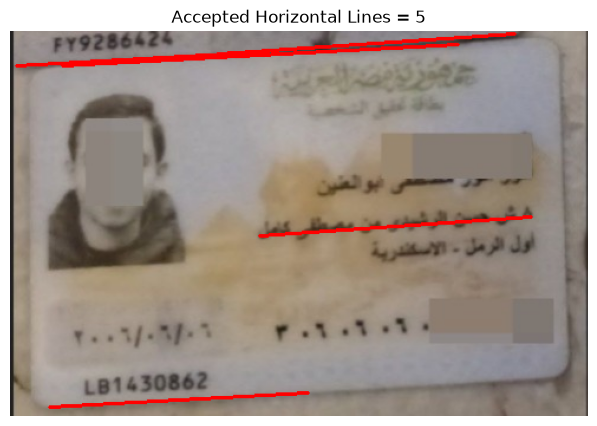

In [39]:
filtered_image = direct_aligned.copy()

accepted_lines = 0

for line in lines:

    x1, y1, x2, y2 = line[0]

    length = np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    angle = np.degrees(
        np.arctan2(
            y2 - y1,
            x2 - x1
        )
    )

    if length > 200 and abs(angle) < 10:

        cv2.line(
            filtered_image,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            2
        )

        accepted_lines += 1

plt.figure(figsize=(10, 5))

plt.imshow(
    cv2.cvtColor(
        filtered_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Accepted Horizontal Lines = {accepted_lines}"
)

plt.axis("off")

plt.show()

In [40]:
angle = np.median(angles)

print("Angles:", angles)
print("Median angle:", angle)

Angles: [np.float64(-3.075621641079249), np.float64(-3.209486317791986), np.float64(-3.1363583683325875), np.float64(-3.874673203565136), np.float64(-3.9793824526782045)]
Median angle: -3.209486317791986


In [41]:
h, w = direct_aligned.shape[:2]

print("Height:", h)
print("Width:", w)

Height: 326
Width: 489


In [42]:
center = (
    w // 2,
    h // 2
)

print("Center:", center)

Center: (244, 163)


In [43]:
M = cv2.getRotationMatrix2D(
    center,
    angle,
    1.0
)

print(M)

[[    0.99843   -0.055987      9.5086]
 [   0.055987     0.99843     -13.405]]


In [44]:
rotated2 = cv2.warpAffine(
    direct_aligned,
    M,
    (w, h),
    flags=cv2.INTER_CUBIC,
    borderMode=cv2.BORDER_REPLICATE
)

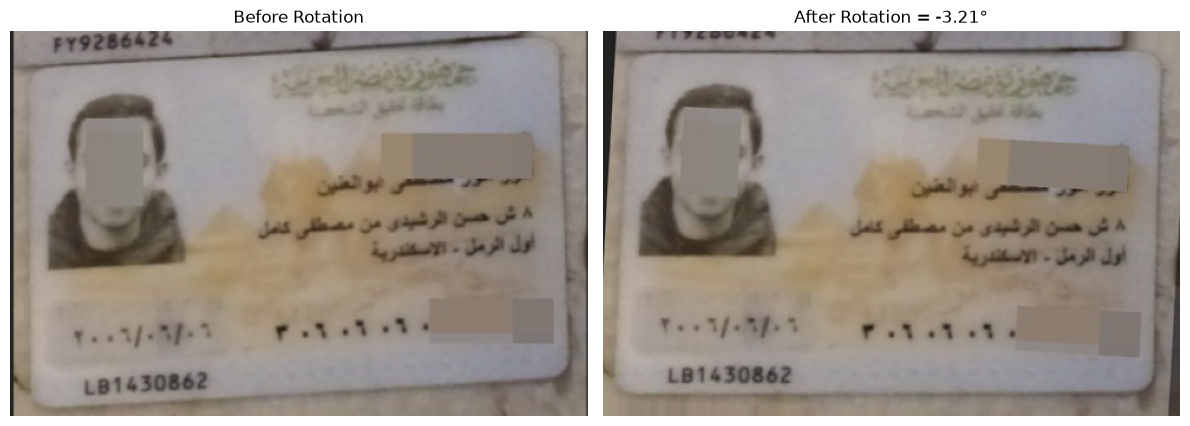

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(
        direct_aligned,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Before Rotation")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    cv2.cvtColor(
        rotated2,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"After Rotation = {angle:.2f}°"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [46]:
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
results = model(rotated2)
result =results[0]
x1, y1, x2, y2 = result.boxes.xyxy[0].int().tolist()


0: 448x640 1 front-up, 55.7ms
Speed: 2.5ms preprocess, 55.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


In [47]:
image = rotated2.copy()

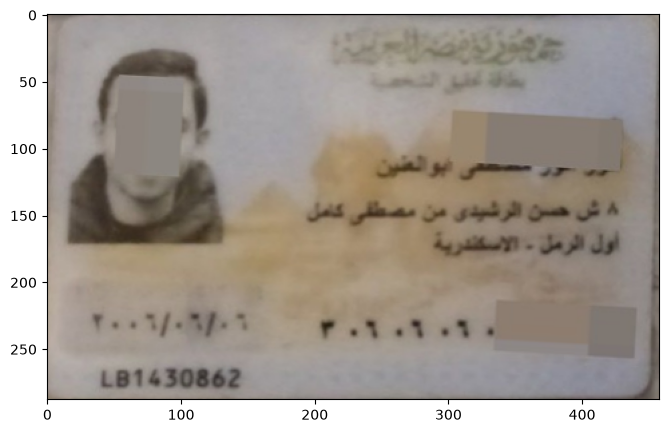

In [48]:
card = image[y1:y2, x1:x2]
plt.figure(figsize=(8, 5))
plt.imshow(
    cv2.cvtColor(
        card,
        cv2.COLOR_BGR2RGB
    )
)